In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import ssms
import lanfactory

In [2]:
# Specify model
model = "angle"

model_dir = Path("../data/torch_models") / model
state_dict_path = next(model_dir.glob("*state_dict*"))
network_config_path = next(model_dir.glob("*network_config*"))

# get_torch_mlp needs the input dimension: params + rt + choice
params = ssms.config.model_config[model]["params"]
input_dim = len(params) + 2

lan_angle = lanfactory.network_inspectors.get_torch_mlp(
    model_file_path=str(state_dict_path),
    network_config=str(network_config_path),
    input_dim=input_dim,
)

Setting network type to "lan" or "cpn" based on train_output_type. 
Note: This is only a default setting, and can be overwritten by the network_type argument.
tanh
tanh
linear


In [3]:
# pick a parameter vector for the model and repeat it across 200 rows
parameter_vector = np.array(
    ssms.config.model_config[model]["default_params"], dtype=np.float32
)
parameter_matrix = np.tile(parameter_vector, (200, 1))

In [4]:
# Initialize network input
network_input = np.zeros((parameter_matrix.shape[0], parameter_matrix.shape[1] + 2))

# Add reaction times
network_input[:, -2] = np.linspace(0, 3, parameter_matrix.shape[0])

# Add choices
network_input[:, -1] = np.repeat(np.random.choice([-1, 1]), parameter_matrix.shape[0])

# The network expects float32 inputs
network_input = network_input.astype(np.float32)

# Show example output
print("Some network outputs")
print(lan_angle(network_input)[:10])
print("Shape")
print(lan_angle(network_input).shape)

Some network outputs
[[-1.387125  ]
 [-0.85837126]
 [-0.4940896 ]
 [-0.26866102]
 [-0.15930986]
 [-0.14436197]
 [-0.20177603]
 [-0.30949783]
 [-0.44699955]
 [-0.5969324 ]]
Shape
(200, 1)


1 of 10


2 of 10


3 of 10


4 of 10


5 of 10


6 of 10


7 of 10


8 of 10


9 of 10


10 of 10


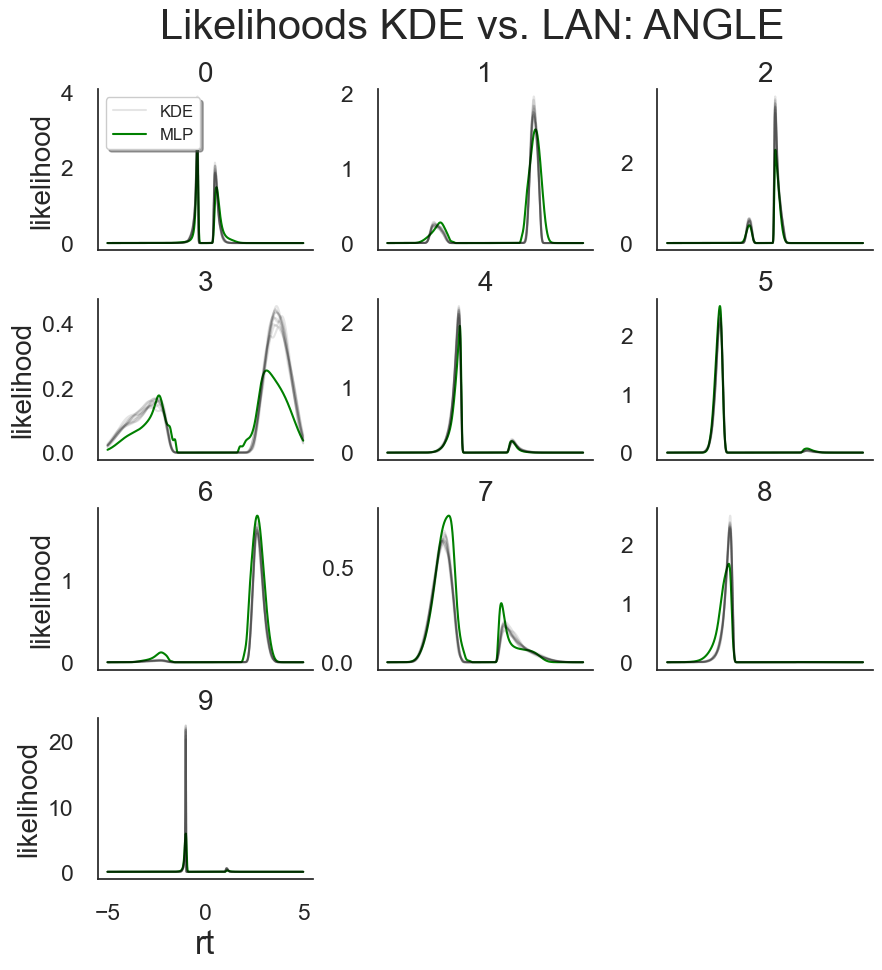

In [5]:
# make 10 reproducible random parameter sets within the model's bounds
rng = np.random.default_rng(123)
lb, ub = ssms.config.model_config[model]["param_bounds"]
parameter_df = pd.DataFrame(
    rng.uniform(lb, ub, size=(10, len(params))), columns=params
)

lanfactory.network_inspectors.kde_vs_lan_likelihoods(
    parameter_df=parameter_df,
    model=model,
    torch_mlp_predict=lan_angle,
    cols=3,
    n_samples=2000,
    n_reps=10,
    show=True,
)

Using only the first row of the supplied parameter array !


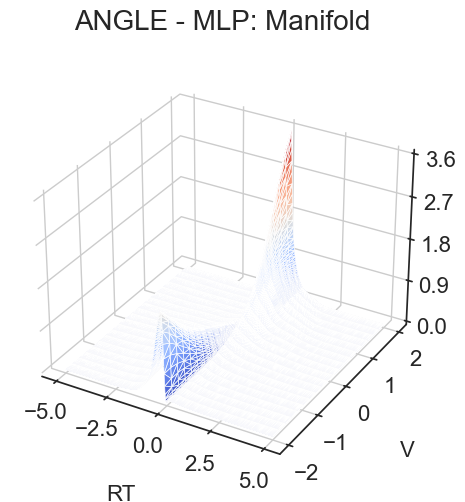

In [6]:
# use a deterministic parameter vector for the manifold plot
manifold_parameter_df = pd.DataFrame(
    [ssms.config.model_config[model]["default_params"]], columns=params
)

lanfactory.network_inspectors.lan_manifold(
    parameter_df=manifold_parameter_df,
    vary_dict={"v": np.linspace(-2, 2, 20)},
    model=model,
    torch_mlp_predict=lan_angle,
    n_rt_steps=300,
    fig_scale=1.0,
    max_rt=5,
    save=True,
    show=True,
)